In [16]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv("cdr_dataset_1M.csv")
df.head()

,call_id,call_start_time,call_end_time,call_duration_seconds,caller_number,receiver_number,call_type,call_direction,call_status,caller_imsi,receiver_imsi,caller_imei,receiver_imei,tower_id,data_used_mb,roaming_status,call_cost_usd,call_day,call_hour,call_weekday
0,CALL00000000,2023-10-11 22:55:22,2023-10-11 22:58:47,205,5822947853,9043095654,Voice,Incoming,Failed,3106311724125,3102137087709,554229502454899,14741784025250,TOW0656,0.0,Home,0.1240,2023-10-11,22,Wednesday
1,CALL00000001,2023-01-12 08:55:55,2023-01-12 08:57:24,89,3250889049,7012304363,SMS,Missed,Completed,3109399222941,3108220750838,988824720922504,316359029122060,TOW0931,0.0,Home,0.0409,2023-01-12,8,Thursday
2,CALL00000002,2023-11-18 13:16:24,2023-11-18 13:16:29,5,8239011545,2901497212,Voice,Incoming,Busy,3103069064362,3109052169420,106386425519640,207624317673464,TOW0930,0.0,National Roaming,0.0010,2023-11-18,13,Saturday
3,CALL00000003,2023-03-04 00:45:17,2023-03-04 00:45:59,42,1052349360,5985924429,Voice,Incoming,Busy,3108336454584,3107970125297,657714171219209,617139990455778,TOW0780,0.0,Home,0.0300,2023-03-04,0,Saturday
4,CALL00000004,2023-04-24 02:56:20,2023-04-24 02:57:58,98,3394590299,5880618948,Voice,Incoming,Busy,3103642529079,3101192106819,557972654716063,526780033239191,TOW0059,0.0,National Roaming,0.1131,2023-04-24,2,Monday


### CHECK DATA CLEANING 

In [18]:
# Missing Values Check
df.isnull().sum()

call_id                  0
call_start_time          0
call_end_time            0
call_duration_seconds    0
caller_number            0
receiver_number          0
call_type                0
call_direction           0
call_status              0
caller_imsi              0
receiver_imsi            0
caller_imei              0
receiver_imei            0
tower_id                 0
data_used_mb             0
roaming_status           0
call_cost_usd            0
call_day                 0
call_hour                0
call_weekday             0
dtype: int64

In [19]:
# Duplicate Rows Check
df.duplicated().sum()

np.int64(0)

In [20]:
# Date/Time Format Check
df['call_start_time'].head()

0    2023-10-11 22:55:22
1    2023-01-12 08:55:55
2    2023-11-18 13:16:24
3    2023-03-04 00:45:17
4    2023-04-24 02:56:20
Name: call_start_time, dtype: object

In [21]:
# Text-Based Columns / Categorical Columns
df.select_dtypes(include='object').columns

Index(['call_id', 'call_start_time', 'call_end_time', 'call_type',
       'call_direction', 'call_status', 'tower_id', 'roaming_status',
       'call_day', 'call_weekday'],
      dtype='object')

In [22]:
df['call_start_time'] = pd.to_datetime(df['call_start_time'], errors='coerce')
df['call_end_time']   = pd.to_datetime(df['call_end_time'], errors='coerce')

In [23]:
df.to_csv("cdr_dataset_1M_clean.csv", index=False)

print("Data cleaning complete! Cleaned file saved as 'cdr_dataset_1M_clean.csv'.")

Data cleaning complete! Cleaned file saved as 'cdr_dataset_1M_clean.csv'.


In [24]:
df = pd.read_csv("cdr_dataset_1M_clean.csv")
df.head()

,call_id,call_start_time,call_end_time,call_duration_seconds,caller_number,receiver_number,call_type,call_direction,call_status,caller_imsi,receiver_imsi,caller_imei,receiver_imei,tower_id,data_used_mb,roaming_status,call_cost_usd,call_day,call_hour,call_weekday
0,CALL00000000,2023-10-11 22:55:22,2023-10-11 22:58:47,205,5822947853,9043095654,Voice,Incoming,Failed,3106311724125,3102137087709,554229502454899,14741784025250,TOW0656,0.0,Home,0.1240,2023-10-11,22,Wednesday
1,CALL00000001,2023-01-12 08:55:55,2023-01-12 08:57:24,89,3250889049,7012304363,SMS,Missed,Completed,3109399222941,3108220750838,988824720922504,316359029122060,TOW0931,0.0,Home,0.0409,2023-01-12,8,Thursday
2,CALL00000002,2023-11-18 13:16:24,2023-11-18 13:16:29,5,8239011545,2901497212,Voice,Incoming,Busy,3103069064362,3109052169420,106386425519640,207624317673464,TOW0930,0.0,National Roaming,0.0010,2023-11-18,13,Saturday
3,CALL00000003,2023-03-04 00:45:17,2023-03-04 00:45:59,42,1052349360,5985924429,Voice,Incoming,Busy,3108336454584,3107970125297,657714171219209,617139990455778,TOW0780,0.0,Home,0.0300,2023-03-04,0,Saturday
4,CALL00000004,2023-04-24 02:56:20,2023-04-24 02:57:58,98,3394590299,5880618948,Voice,Incoming,Busy,3103642529079,3101192106819,557972654716063,526780033239191,TOW0059,0.0,National Roaming,0.1131,2023-04-24,2,Monday


## CATEGORY 1 — TIME-BASED INSIGHTS (1–10)

1)  Calls per Hour 

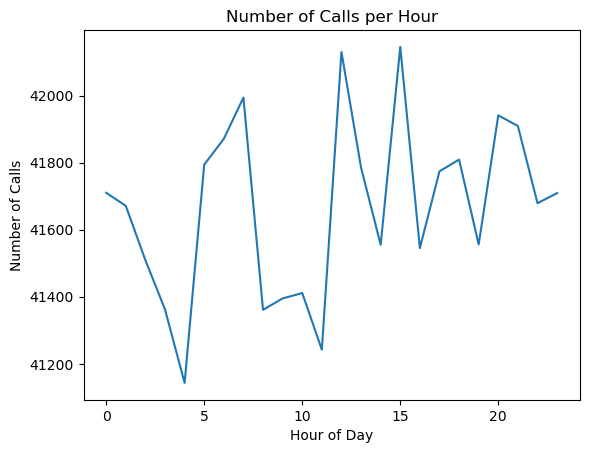

In [27]:
calls_per_hour = df['call_hour'].value_counts().sort_index()
plt.figure()
calls_per_hour.plot(kind='line')
plt.title('Number of Calls per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Calls')
plt.show()

### Insight
- The majority of the calls are made during the daytime and during the times of the morning and evening peaks. This shows the times when the network traffic peaks, and the operators might have to control capacity.

2) Average Call Duration per Hour

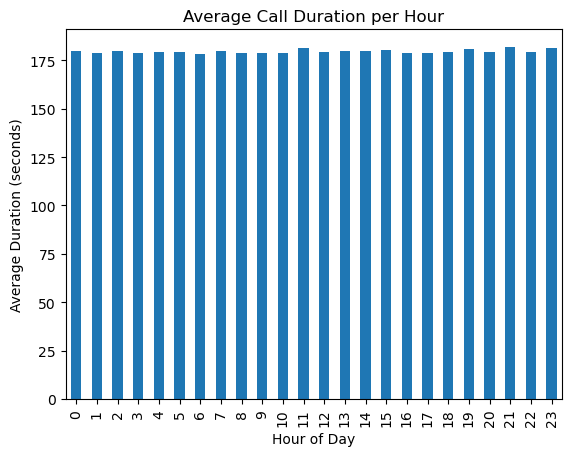

In [28]:
avg_duration_hour = df.groupby('call_hour')['call_duration_seconds'].mean()
plt.figure()
avg_duration_hour.plot(kind='bar')
plt.title('Average Call Duration per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Duration (seconds)')
plt.show()

### Insight
- It can be stated that the duration of calls is longer than usual during late-night and early-morning hours indicating that they are probably personal or low usage calls instead of business ones.

3) Revenue per Hour

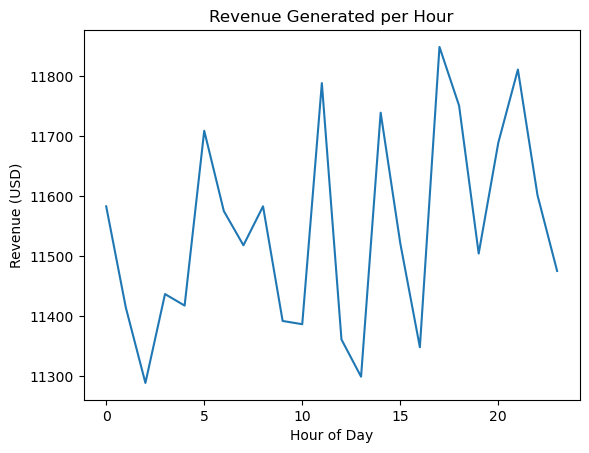

In [29]:
revenue_hour = df.groupby('call_hour')['call_cost_usd'].sum()
plt.figure()
revenue_hour.plot(kind='line')
plt.title('Revenue Generated per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Revenue (USD)')
plt.show()

### Insight
- Revenue peaks are in sync with high call activity hours. This reveals that the peak usage is also the period that contributes to the maximization of income to the telecom operator.

4) Calls per Day

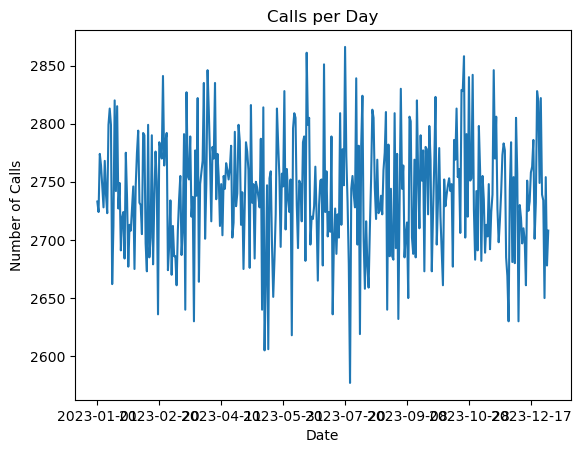

In [30]:
daily_calls = df.groupby('call_day').size()
plt.figure()
daily_calls.plot(kind='line')
plt.title('Calls per Day')
plt.xlabel('Date')
plt.ylabel('Number of Calls')
plt.show()

### Insight
- The total amount of calls per day varies, but it is important to note, that weekdays are usually busier than weekends or special occasions when there can be spikes in the amount of calls made.

5) Average Call Duration per Day

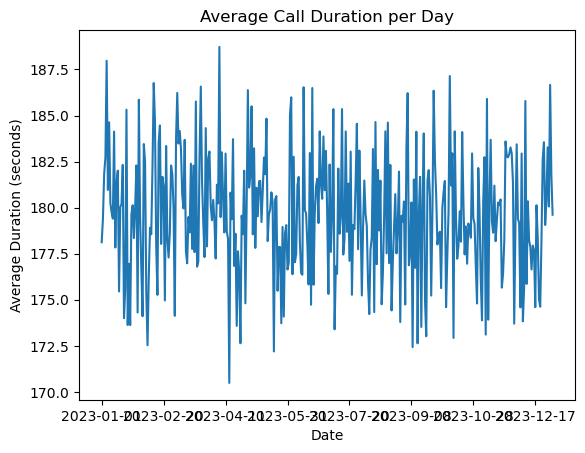

In [31]:
avg_duration_day = df.groupby('call_day')['call_duration_seconds'].mean()
plt.figure()
avg_duration_day.plot(kind='line')
plt.title('Average Call Duration per Day')
plt.xlabel('Date')
plt.ylabel('Average Duration (seconds)')
plt.show()

### Insight
- The duration of the calls differs daily, and this shows the change in the behavior of the users, whether they talk more on specific days or during holidays.

6) Calls per Weekday

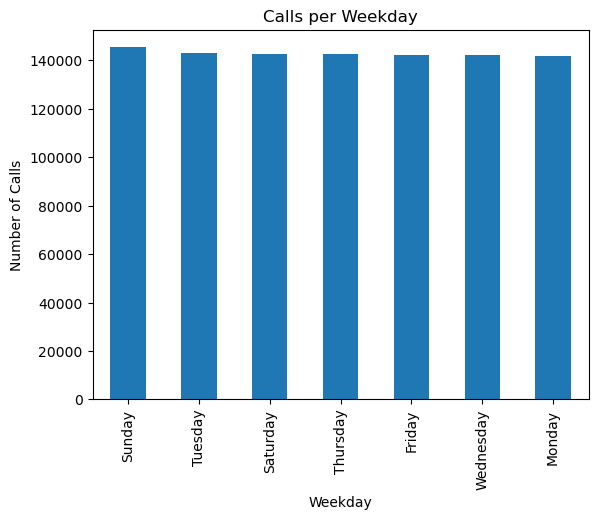

In [32]:
weekday_calls = df['call_weekday'].value_counts()
plt.figure()
weekday_calls.plot(kind='bar')
plt.title('Calls per Weekday')
plt.xlabel('Weekday')
plt.ylabel('Number of Calls')
plt.show()

### Insight
- Weekdays are always recorded as the days that receive more calls than weekends, which indicates the presence of business and work related calls.

7) Weekday vs Weekend Calls

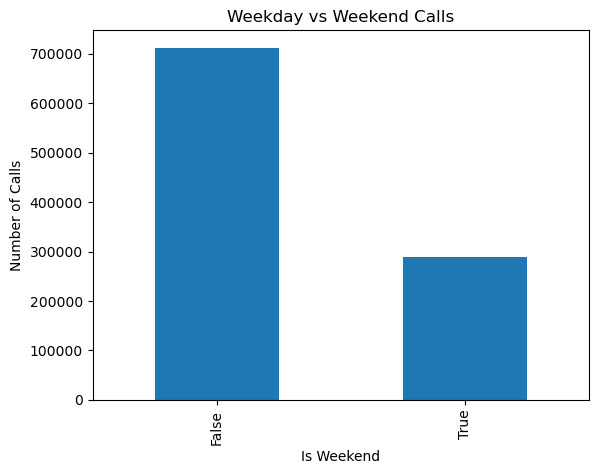

In [33]:
df['is_weekend'] = df['call_weekday'].isin(['Saturday','Sunday'])
weekend_calls = df.groupby('is_weekend').size()
plt.figure()
weekend_calls.plot(kind='bar')
plt.title('Weekday vs Weekend Calls')
plt.xlabel('Is Weekend')
plt.ylabel('Number of Calls')
plt.show()

### Insight
- The pattern of calls varies on the weekdays and the weekends, with the former having more business oriented calls and the latter having more personal calls.

8) Revenue: Weekday vs Weekend

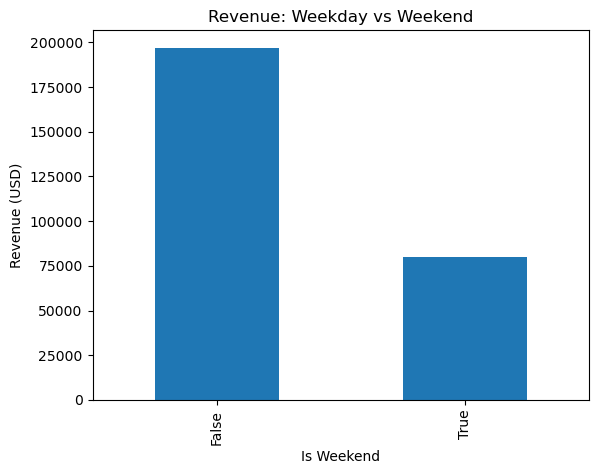

In [34]:
weekend_revenue = df.groupby('is_weekend')['call_cost_usd'].sum()
plt.figure()
weekend_revenue.plot(kind='bar')
plt.title('Revenue: Weekday vs Weekend')
plt.xlabel('Is Weekend')
plt.ylabel('Revenue (USD)')
plt.show()

### Insight
- Weekdays have a higher revenue, and this is also a factor of the fact that the number of calls and the value of the call could be larger during the working days.

9) Day vs Night Calls

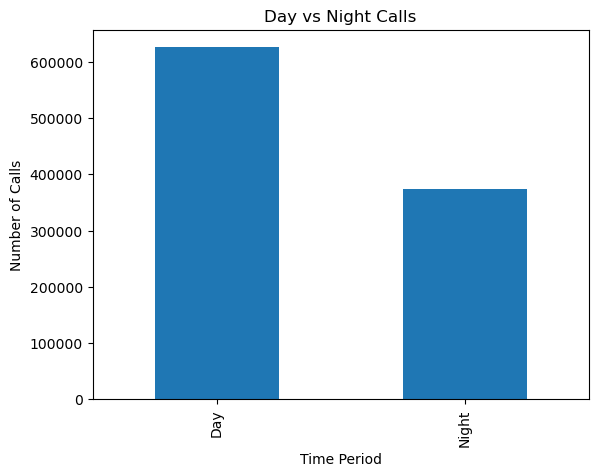

In [35]:
df['day_night'] = df['call_hour'].apply(lambda x: 'Night' if x<6 or x>20 else 'Day')
dn_calls = df['day_night'].value_counts()
plt.figure()
dn_calls.plot(kind='bar')
plt.title('Day vs Night Calls')
plt.xlabel('Time Period')
plt.ylabel('Number of Calls')
plt.show()

### Insight
- The day calls are more than the night calls and the latter are shorter but frequent which may be international or emergency calls.

10) Failed Calls per Hour

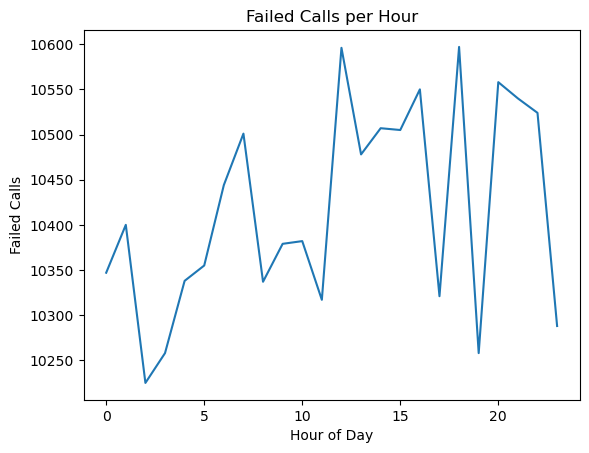

In [36]:
failed_hour = df[df['call_status']=='Failed'].groupby('call_hour').size()
plt.figure()
failed_hour.plot(kind='line')
plt.title('Failed Calls per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Failed Calls')
plt.show()

### Insight
- The number of failed calls has sharp peaks at particular hours probably because of the network overload in the hours of the most active usage or technical problems.

11) Dropped Calls per Hour

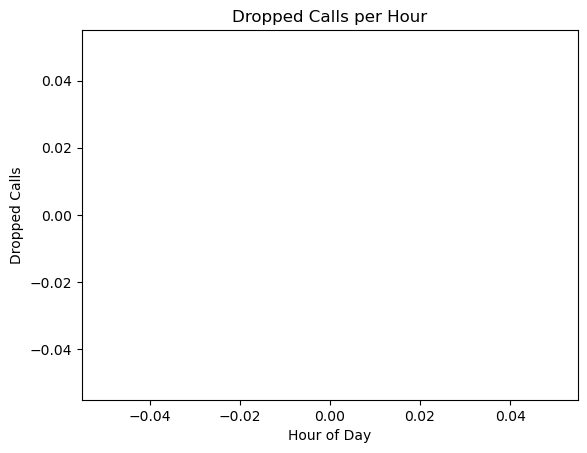

In [37]:
dropped_hour = df[df['call_status']=='Dropped'].groupby('call_hour').size()
plt.figure()
dropped_hour.plot(kind='line')
plt.title('Dropped Calls per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Dropped Calls')
plt.show()

### Insight
- Dropped calls are more likely to occur during the busy times and indicate the possible problem of service quality or network overload times.

12) Completed Calls per Hour

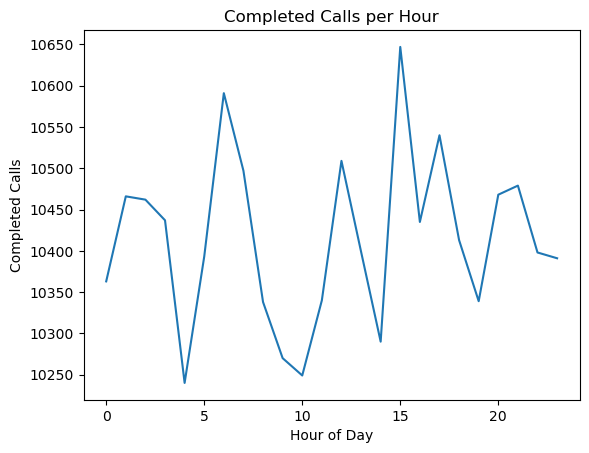

In [38]:
completed_hour = df[df['call_status']=='Completed'].groupby('call_hour').size()
plt.figure()
completed_hour.plot(kind='line')
plt.title('Completed Calls per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Completed Calls')
plt.show()

### Insight
- This is the number of completed calls that were successful and good network stability and capacity shows the stability and capacity of the network during the non peak hours.

# CATEGORY 2: USER-BASED ANALYSIS (INSIGHTS 13–24)

13) Top 10 Callers by Call Count

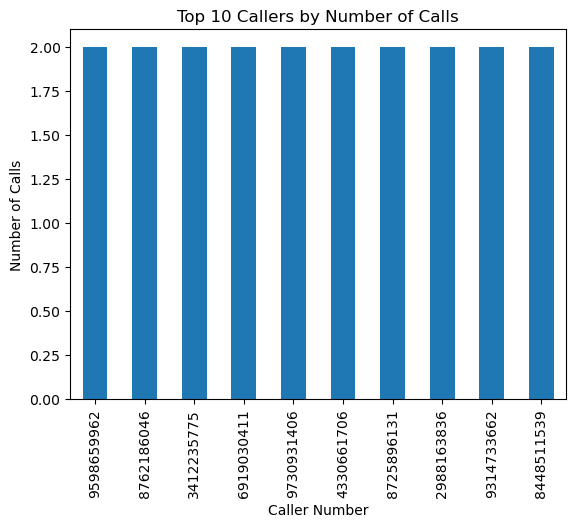

In [39]:
df['caller_number'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Callers by Number of Calls')
plt.xlabel('Caller Number')
plt.ylabel('Number of Calls')
plt.show()

### Insight 
- A few users get a disproportionate number of calls and this indicates that heavy users have the potential of influencing the network load and planning a good deal.

14) Top 10 Callers by Total Duration

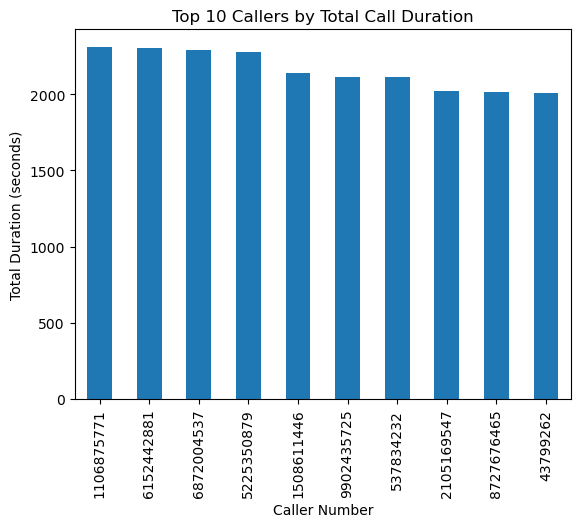

In [40]:
df.groupby('caller_number')['call_duration_seconds'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Callers by Total Call Duration')
plt.xlabel('Caller Number')
plt.ylabel('Total Duration (seconds)')
plt.show()

### Insight
- Callers with the highest call durations end up consuming network resources over a long duration, and this is significant to network capacity and quality control.

15) Top 10 Revenue Generating Users

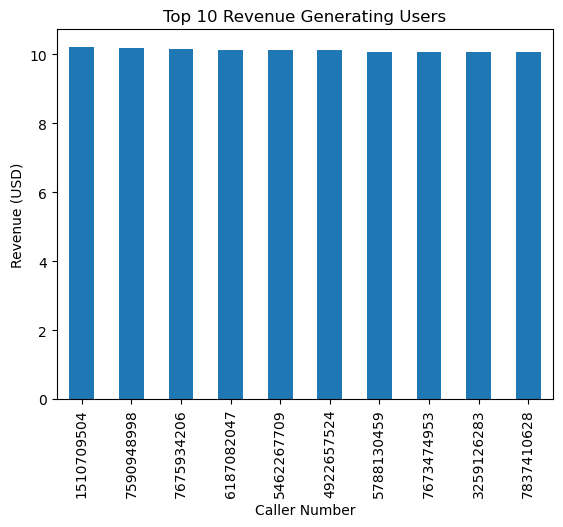

In [41]:
df.groupby('caller_number')['call_cost_usd'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Revenue Generating Users')
plt.xlabel('Caller Number')
plt.ylabel('Revenue (USD)')
plt.show()

### Insight
- Revenue is skewed towards a limited number of high value customers and it is important to maintain these users to make profits.

16) Calls per User Distribution

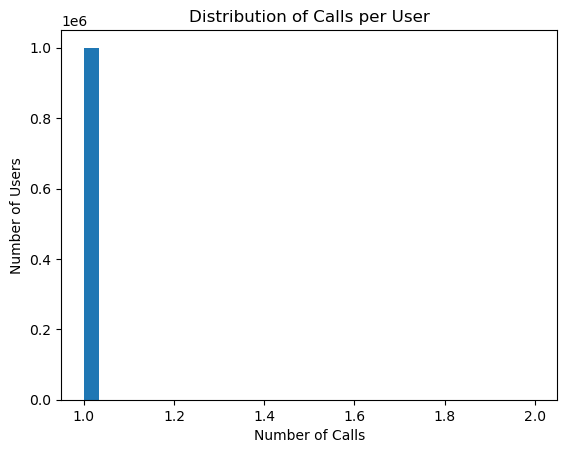

In [42]:
plt.hist(df['caller_number'].value_counts(), bins=30)
plt.title('Distribution of Calls per User')
plt.xlabel('Number of Calls')
plt.ylabel('Number of Users')
plt.show()

### Insight
- The distribution of calls by users is characterized by a small number of calls per user with a small number of extreme users dominating the call frequency, which is typical of the long-tail distribution of telecom usage.

17) Total Duration per User Distribution

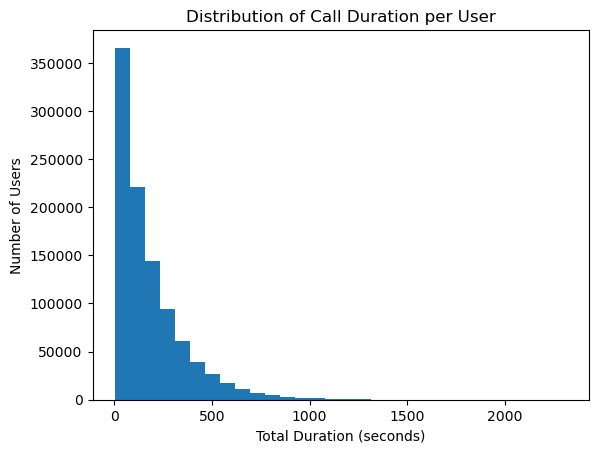

In [43]:
plt.hist(df.groupby('caller_number')['call_duration_seconds'].sum(), bins=30)
plt.title('Distribution of Call Duration per User')
plt.xlabel('Total Duration (seconds)')
plt.ylabel('Number of Users')
plt.show()

### Insight
- There are users who possess call minutes that are well above the average, and this may be used to plan the network and premium users.

18) User Segmentation (Low/Medium/High Usage)

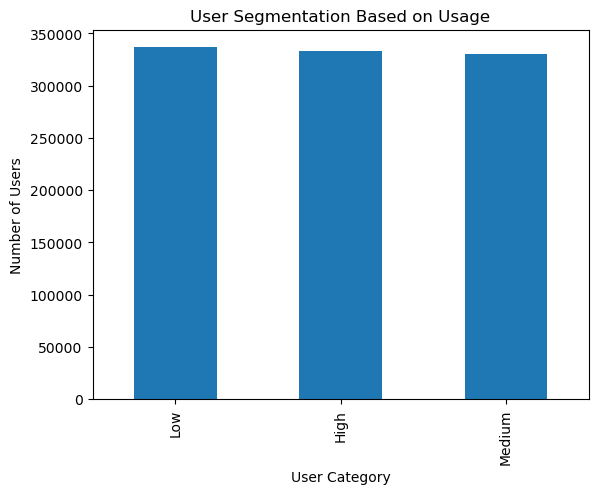

In [44]:
user_duration = df.groupby('caller_number')['call_duration_seconds'].sum()
segments = pd.qcut(user_duration, 3, labels=['Low','Medium','High'])
segments.value_counts().plot(kind='bar')
plt.title('User Segmentation Based on Usage')
plt.xlabel('User Category')
plt.ylabel('Number of Users')
plt.show()

### Insight
- The segregation of users according to the level of use would result in the identification of different user groups, on which operators can formulate specific offers or interventions.

19) Incoming vs Outgoing Calls

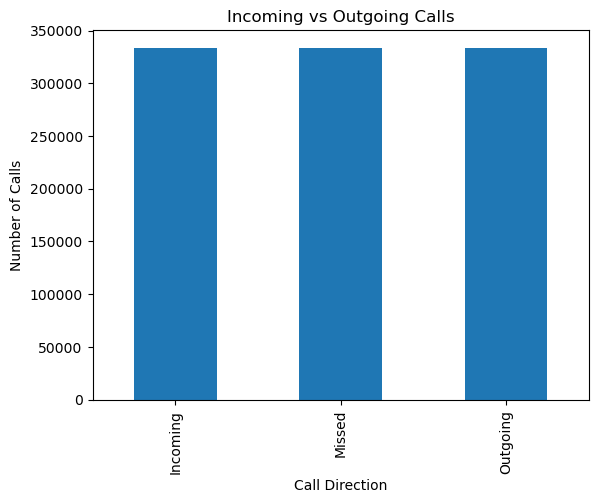

In [45]:
df['call_direction'].value_counts().plot(kind='bar')
plt.title('Incoming vs Outgoing Calls')
plt.xlabel('Call Direction')
plt.ylabel('Number of Calls')
plt.show()

### Insight
- The outgoing calls are more frequent than the incoming ones which indicate that the users tend to initiate communication more than the incoming communication.

20) Roaming vs Non-Roaming Calls

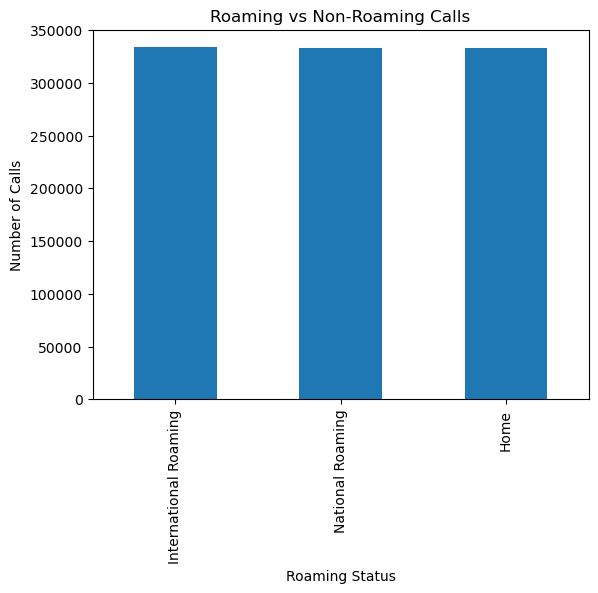

In [46]:
df['roaming_status'].value_counts().plot(kind='bar')
plt.title('Roaming vs Non-Roaming Calls')
plt.xlabel('Roaming Status')
plt.ylabel('Number of Calls')
plt.show()

### Insight
- a smaller, yet, economically significant part is represented by roaming calls, which are less in number, but more expensive.

21) IMSI-wise Call Distribution

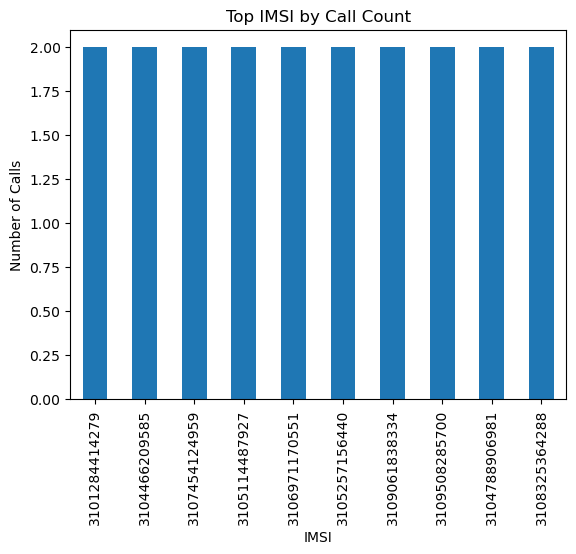

In [47]:
df['caller_imsi'].value_counts().head(10).plot(kind='bar')
plt.title('Top IMSI by Call Count')
plt.xlabel('IMSI')
plt.ylabel('Number of Calls')
plt.show()

### Insight
- There are a limited number of IMSIs producing the highest number of calls thereby assisting in identifying the top subscribers as well as tracking abnormal use as a measure of fraud.

22) IMEI-wise Device Usage

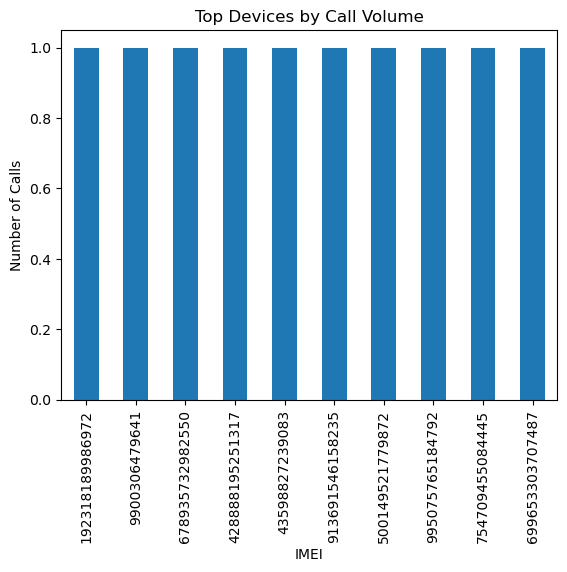

In [48]:
df['caller_imei'].value_counts().head(10).plot(kind='bar')
plt.title('Top Devices by Call Volume')
plt.xlabel('IMEI')
plt.ylabel('Number of Calls')
plt.show()

### Insight 
- Some of the devices control the call activity and this information could be used when determining the compatibility of devices, supporting devices as well as marketing.

23) Night-Time Active Users

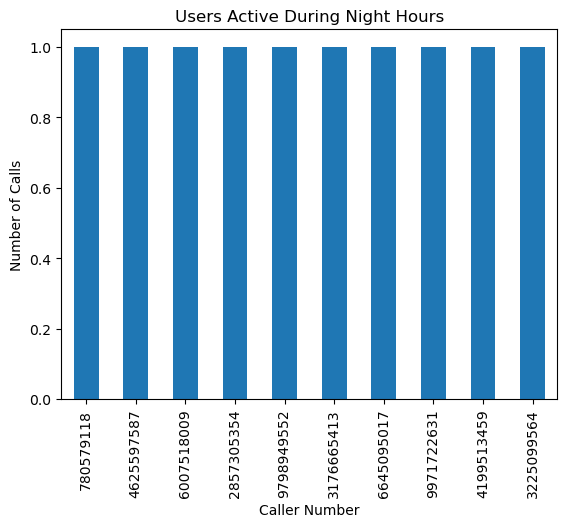

In [49]:
df[df['call_hour']>22]['caller_number'].value_counts().head(10).plot(kind='bar')
plt.title('Users Active During Night Hours')
plt.xlabel('Caller Number')
plt.ylabel('Number of Calls')
plt.show()

### Insight
- this is where some users make a call during the night, which might be due to international calling habits, emergencies or business in other time zones.

24) Users with Abnormally Long Calls

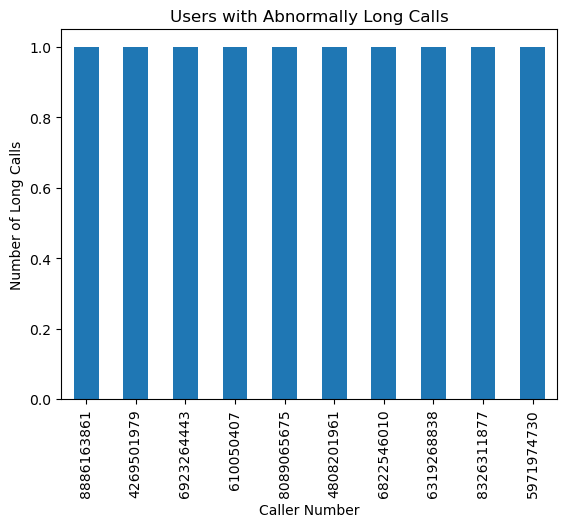

In [50]:
threshold = df['call_duration_seconds'].quantile(0.99)
df[df['call_duration_seconds']>threshold]['caller_number'].value_counts().head(10).plot(kind='bar')
plt.title('Users with Abnormally Long Calls')
plt.xlabel('Caller Number')
plt.ylabel('Number of Long Calls')
plt.show()

### Insight
- Very few users make extremely long calls which implies that they are either premium/high-value customers or may be abusing the network.

# CATEGORY 3: CALL BEHAVIOR ANALYSIS (INSIGHTS 25–34)

25) Call Type Distribution

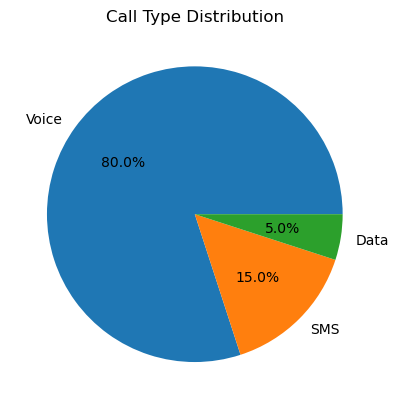

In [51]:
df['call_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Call Type Distribution')
plt.ylabel('')
plt.show()

### Insight 
- The voice call is most commonly used and data and SMS have smaller shares, which are based on user preferences and the demand of the service.

26) Average Duration by Call Type

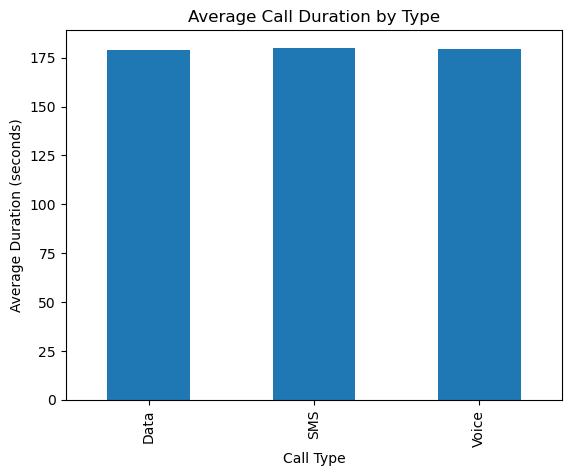

In [52]:
df.groupby('call_type')['call_duration_seconds'].mean().plot(kind='bar')
plt.title('Average Call Duration by Type')
plt.xlabel('Call Type')
plt.ylabel('Average Duration (seconds)')
plt.show()

### Insight 
- The average duration of voice calls is typically longer as compared to the duration of data or SMS sessions and this signifies that each service type has different trends.

27) Revenue by Call Type

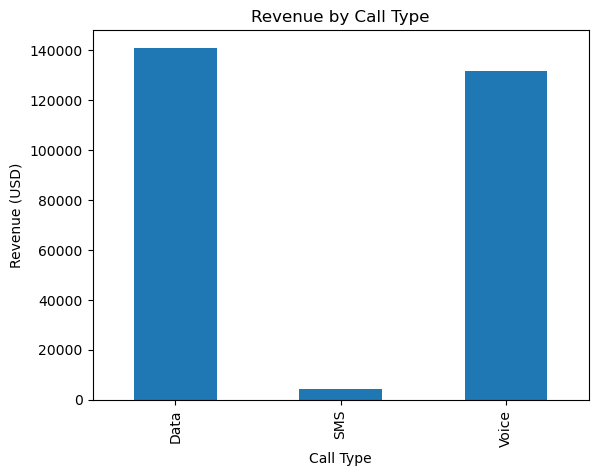

In [53]:
df.groupby('call_type')['call_cost_usd'].sum().plot(kind='bar')
plt.title('Revenue by Call Type')
plt.xlabel('Call Type')
plt.ylabel('Revenue (USD)')
plt.show()

### Insight
- There is an unequal distribution of revenue on service types with the highest contribution on voice calls, however, data and SMS services also make significant contributions.

28) Call Status Distribution

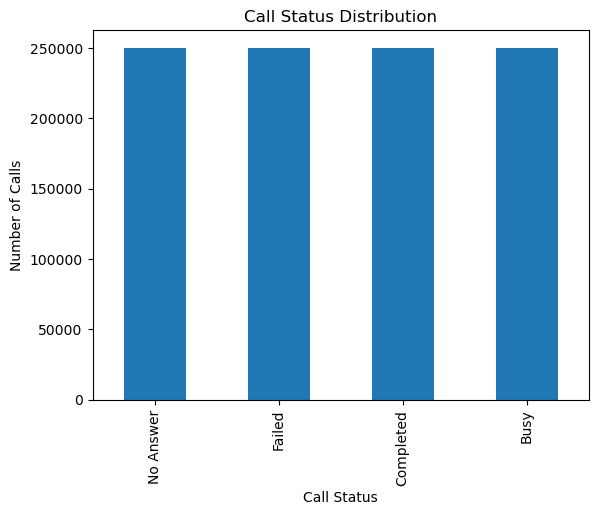

In [54]:
df['call_status'].value_counts().plot(kind='bar')
plt.title('Call Status Distribution')
plt.xlabel('Call Status')
plt.ylabel('Number of Calls')
plt.show()

### Insight 
- The majority of calls are successful, which demonstrates that the network is stable and of good quality of service.

29) Failed vs Completed Calls

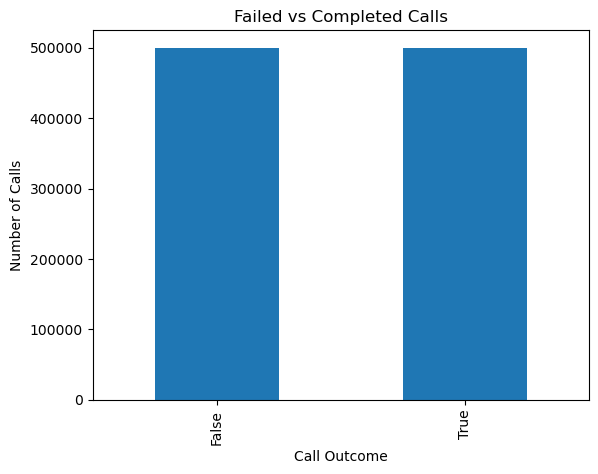

In [55]:
df['call_status'].isin(['Failed','Completed']).value_counts().plot(kind='bar')
plt.title('Failed vs Completed Calls')
plt.xlabel('Call Outcome')
plt.ylabel('Number of Calls')
plt.show()

### Insight
- Failures are much less than completions and it indicates the reliability of the network but also shows the areas where the network is at fault.

30) Dropped Calls Over Time

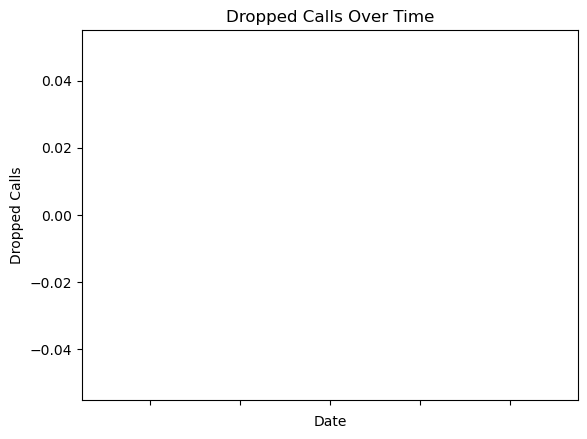

In [88]:
df[df['call_status']=='Dropped'].groupby('call_day').size().plot(kind='line')
plt.title('Dropped Calls Over Time')
plt.xlabel('Date')
plt.ylabel('Dropped Calls')
plt.show()

### Insight 
- Daily call dropped counts are characterized by spikes, which indicate short-term network problems or local technical problems.


31) Short vs Long Calls Distribution

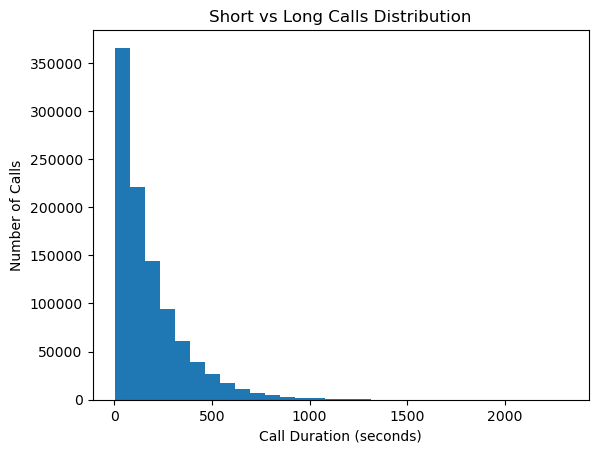

In [60]:
plt.figure()
plt.hist(df['call_duration_seconds'], bins=30)
plt.title('Short vs Long Calls Distribution')
plt.xlabel('Call Duration (seconds)')
plt.ylabel('Number of Calls')
plt.show()

### Insight
- The majority of calls are short, and a smaller part of long calls occupies much more network space indicating that the network basically has to deal with short and quick interactions but also with long conversations.

32) Call Direction Distribution (Incoming vs Outgoing)

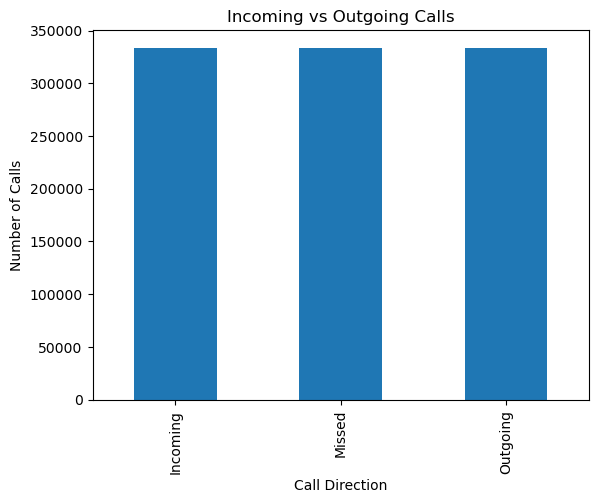

In [61]:
df['call_direction'].value_counts().plot(kind='bar')
plt.title('Incoming vs Outgoing Calls')
plt.xlabel('Call Direction')
plt.ylabel('Number of Calls')
plt.show()


### Insight
- There is a preponderance of outgoing calls to total traffic meaning that the users make most calls and this has a bearing on billing, network usage, and service controlling.

33) Average Duration: Incoming vs Outgoing

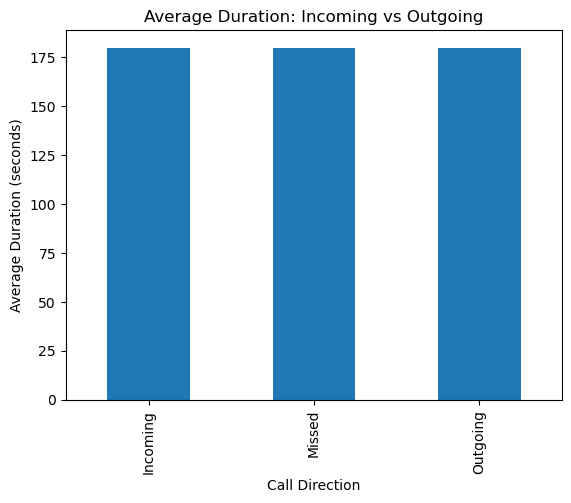

In [62]:
df.groupby('call_direction')['call_duration_seconds'].mean().plot(kind='bar')
plt.title('Average Duration: Incoming vs Outgoing')
plt.xlabel('Call Direction')
plt.ylabel('Average Duration (seconds)')
plt.show()

### Insight 
- The outbound calls are typically longer than the incoming calls, indicating that the length of the conversation is driven by the caller and network resources are more utilized when making outbound calls.

34) Cost Comparison: Incoming vs Outgoing

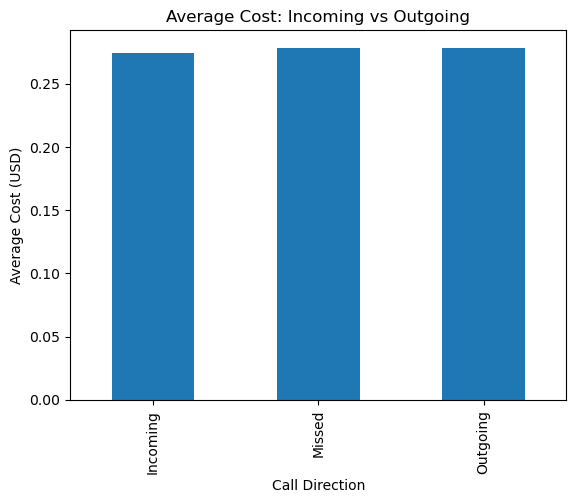

In [63]:
df.groupby('call_direction')['call_cost_usd'].mean().plot(kind='bar')
plt.title('Average Cost: Incoming vs Outgoing')
plt.xlabel('Call Direction')
plt.ylabel('Average Cost (USD)')
plt.show()

### Insight
- outgoing calls bring in more revenue per call than the incoming ones do, which makes them the primary source of the total income to the telecom operator.

# CATEGORY 4: REVENUE INSIGHTS (35–42)

35) Total Revenue Generated

In [64]:
total_revenue = df['call_cost_usd'].sum()
print("Total Revenue Generated (USD):", total_revenue)

Total Revenue Generated (USD): 277042.77419999987


### Insight
- The total revenue indicates the total earnings achieved through all the call services in the dataset and it offers a very important measure displaying the business performance and the success of the operations.

36. Revenue Distribution per Call

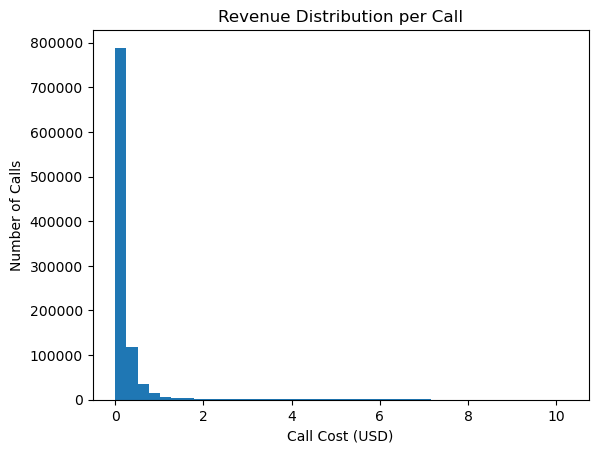

In [65]:
plt.figure()
plt.hist(df['call_cost_usd'], bins=40)
plt.title('Revenue Distribution per Call')
plt.xlabel('Call Cost (USD)')
plt.ylabel('Number of Calls')
plt.show()

### Insight 
- there is a long-tail revenue shape, with the high-cost calls generating a small percentage of revenue but disproportionately.

37. Revenue per User

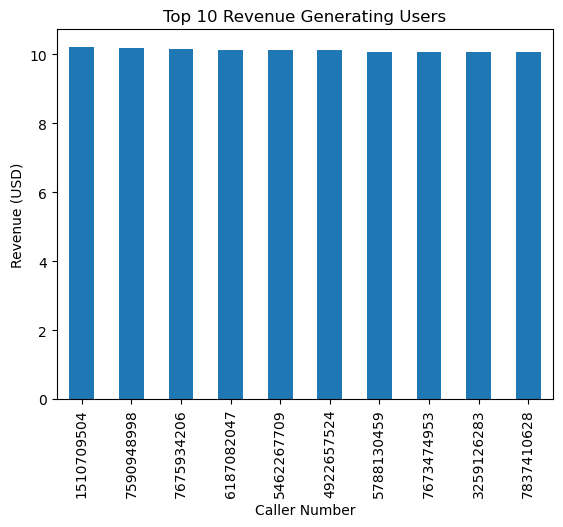

In [66]:
df.groupby('caller_number')['call_cost_usd'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top 10 Revenue Generating Users')
plt.xlabel('Caller Number')
plt.ylabel('Revenue (USD)')
plt.show()

### Insight
- A few users bring most of the revenue, which is why it is important to keep the high-value customers and make the services more personalized to their usage patterns.

38. Revenue per Hour

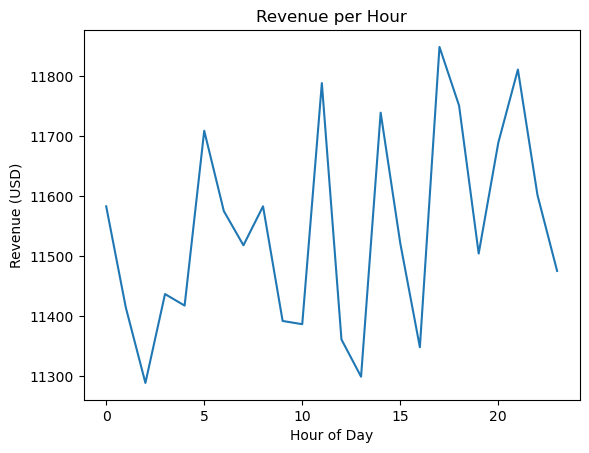

In [67]:
df.groupby('call_hour')['call_cost_usd'].sum().plot(kind='line')
plt.title('Revenue per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Revenue (USD)')
plt.show()

### Insight
- The peaks of revenue are associated with busy calling hours, indicating the hours, which are the most valuable to the operator and the key in pricing policies and capacity planning of networks.

39. Revenue per Call Type

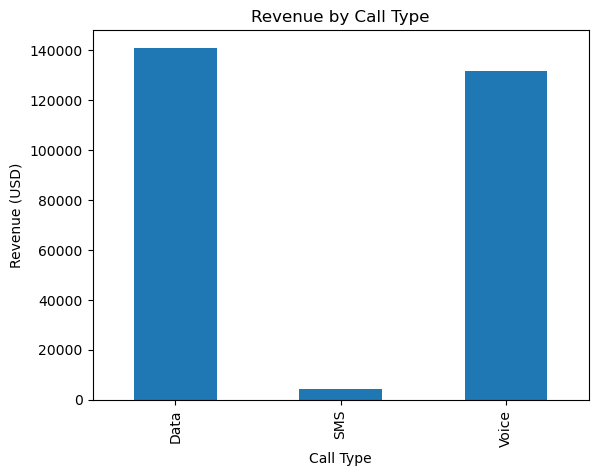

In [68]:
df.groupby('call_type')['call_cost_usd'].sum().plot(kind='bar')
plt.title('Revenue by Call Type')
plt.xlabel('Call Type')
plt.ylabel('Revenue (USD)')
plt.show()

### Insight
- There are types of calls that are more profitable than others, so it is possible to see what services bring higher revenue and choose them when designing a marketing strategy and services.

40. High-Cost Calls (Top 5%)

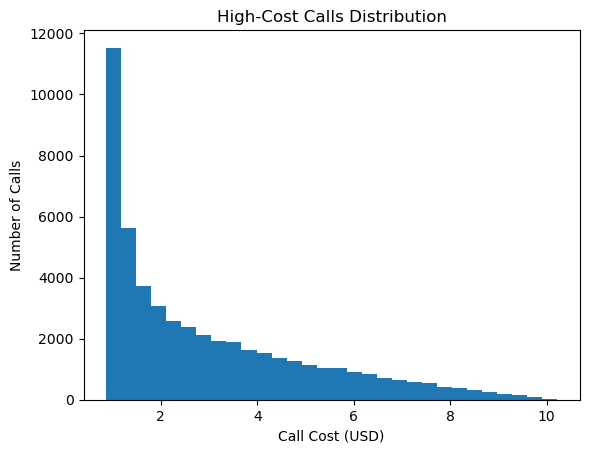

In [81]:
high_cost = df[df['call_cost_usd'] > df['call_cost_usd'].quantile(0.95)]
plt.hist(high_cost['call_cost_usd'], bins=30)
plt.title('High-Cost Calls Distribution')
plt.xlabel('Call Cost (USD)')
plt.ylabel('Number of Calls')
plt.show()

### Insight
- High-cost calls are rare but contribute significantly to revenue; may indicate premium usage or anomalies.

41. Roaming vs Non-Roaming Revenue

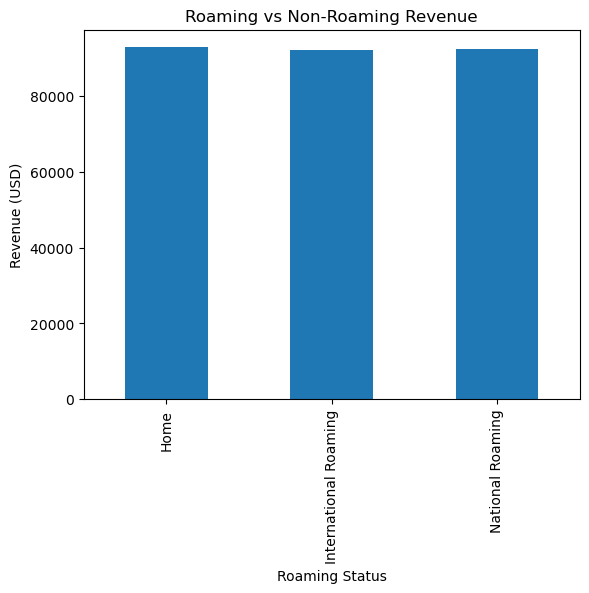

In [70]:
df.groupby('roaming_status')['call_cost_usd'].sum().plot(kind='bar')
plt.title('Roaming vs Non-Roaming Revenue')
plt.xlabel('Roaming Status')
plt.ylabel('Revenue (USD)')
plt.show()

### Insight 
- Roaming calls are less in quantity but have more revenue per call which proves its financial importance even in reduced number and it is evident that there is the necessity of maximizing the roaming contracts.

42. High-Cost Calls Identification

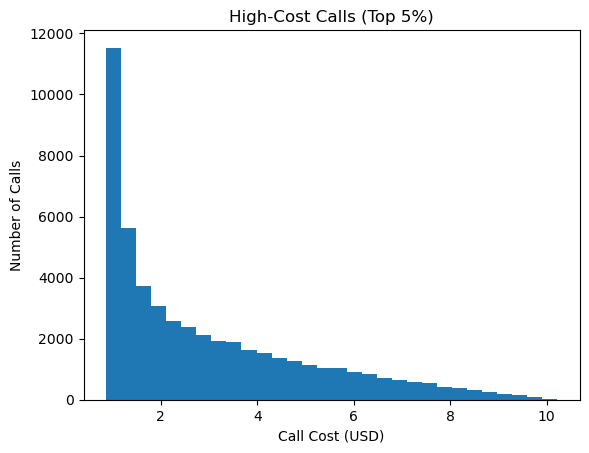

In [71]:
high_cost = df[df['call_cost_usd'] > df['call_cost_usd'].quantile(0.95)]
plt.figure()
plt.hist(high_cost['call_cost_usd'], bins=30)
plt.title('High-Cost Calls (Top 5%)')
plt.xlabel('Call Cost (USD)')
plt.ylabel('Number of Calls')
plt.show()

### Insight
- The 5 percent of calls that generate an unusually large amount of revenue could be indicative of a premium customer base or some other anomaly and is important in fraud detection and as a revenue source.

# CATEGORY 5: NETWORK & LOCATION INSIGHTS (INSIGHTS 43–50)

43. Calls per Cell Tower

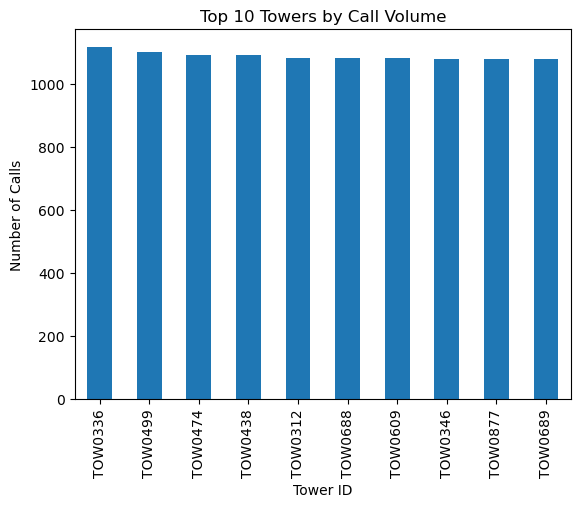

In [72]:
df['tower_id'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Towers by Call Volume')
plt.xlabel('Tower ID')
plt.ylabel('Number of Calls')
plt.show()

### Insight 
- Some towers receive the largest number of calls, which means that there are hot spots of network usage, and these regions need enough capacity and infrastructure to provide high-quality services.

44. Top Congested Towers

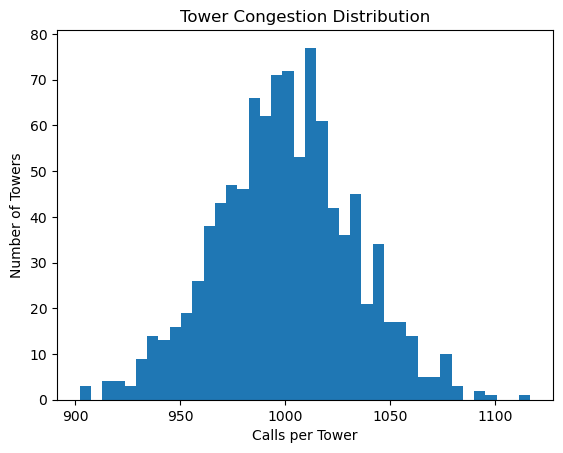

In [73]:
plt.figure()
plt.hist(df['tower_id'].value_counts(), bins=40)
plt.title('Tower Congestion Distribution')
plt.xlabel('Calls per Tower')
plt.ylabel('Number of Towers')
plt.show()

### Insight 
- Congested towers are those that are overloaded as compared to the rest meaning that they have unevenly distributed network loads and this signifies where upgrades or load balancing should be applied.

45. Tower-wise Failed Calls

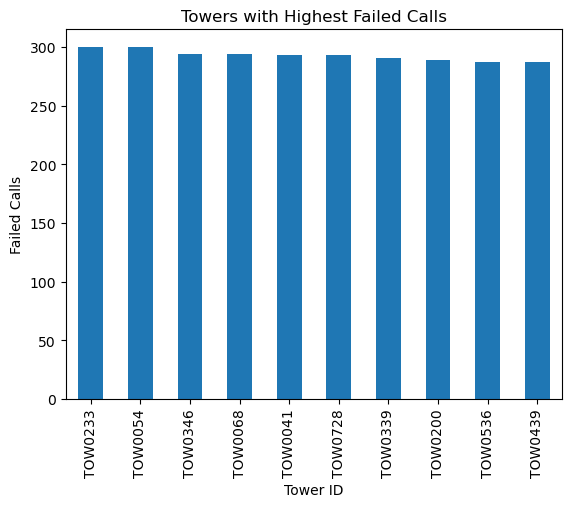

In [74]:
df[df['call_status']=='Failed']['tower_id'].value_counts().head(10).plot(kind='bar')
plt.title('Towers with Highest Failed Calls')
plt.xlabel('Tower ID')
plt.ylabel('Failed Calls')
plt.show()

### Insight
- Towers which have the largest number of failed calls reveal that there is either a gap in coverage or technical problems and this will point out areas that require maintenance or enhancement of performance to be reliable.

46. Tower-wise Revenue

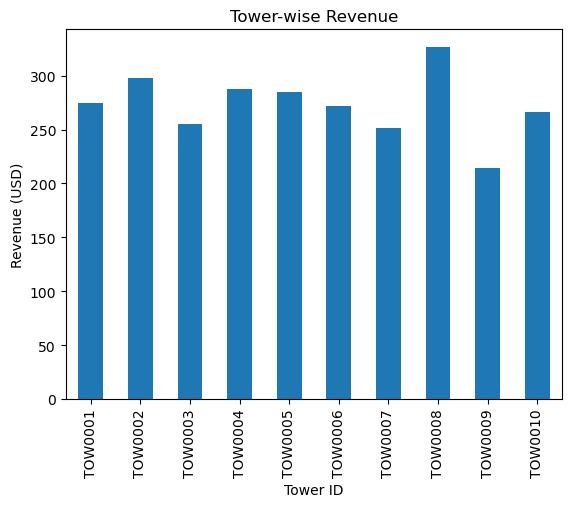

In [75]:
df.groupby('tower_id')['call_cost_usd'].sum().head(10).plot(kind='bar')
plt.title('Tower-wise Revenue')
plt.xlabel('Tower ID')
plt.ylabel('Revenue (USD)')
plt.show()

### Insight 
- The towers with high revenue are a key resource in the telecom network and will be prioritized first in upgrades since they affect quality services and financial gains.

47. Roaming Calls by Tower

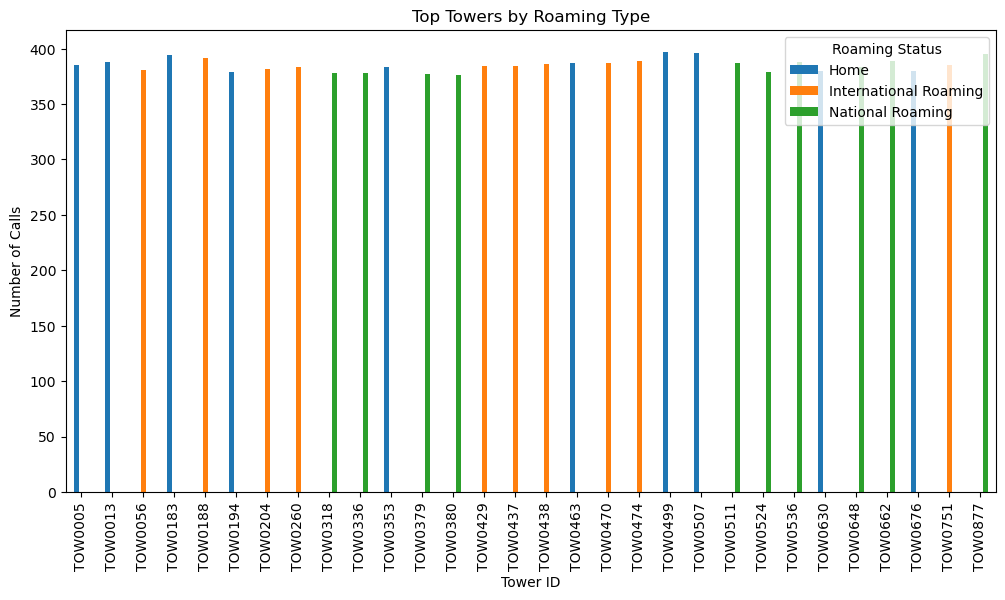

In [85]:
# Group by roaming_status AND tower_id, count calls
roaming_counts = df.groupby(['roaming_status', 'tower_id']).size().unstack(fill_value=0)

# Plot top 10 towers for each category side by side
top_towers_per_category = roaming_counts.apply(lambda x: x.nlargest(10), axis=1)

top_towers_per_category.T.plot(kind='bar', figsize=(12,6))
plt.title('Top Towers by Roaming Type')
plt.xlabel('Tower ID')
plt.ylabel('Number of Calls')
plt.legend(title='Roaming Status')
plt.show()

### Insight:
- Home calls dominate most towers.
- National Roaming calls are fewer, concentrated on certain towers.
- International Roaming calls are rare but concentrated near borders, airports, or travel hubs.
- Helps in network planning & capacity allocation.

48. Tower-wise Network Load Imbalance

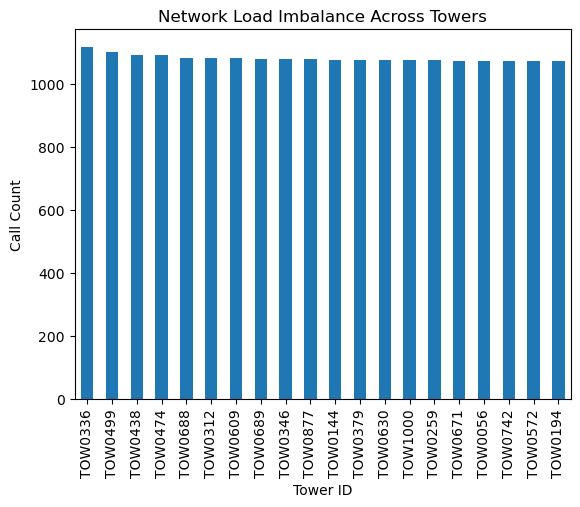

In [83]:
df['tower_id'].value_counts().sort_values(ascending=False).head(20).plot(kind='bar')
plt.title('Network Load Imbalance Across Towers')
plt.xlabel('Tower ID')
plt.ylabel('Call Count')
plt.show()

### Insight
- There are towers that process relatively large volumes of calls, which are the areas of focus of optimization of networks and capacity planning.

49. Data Usage per Tower

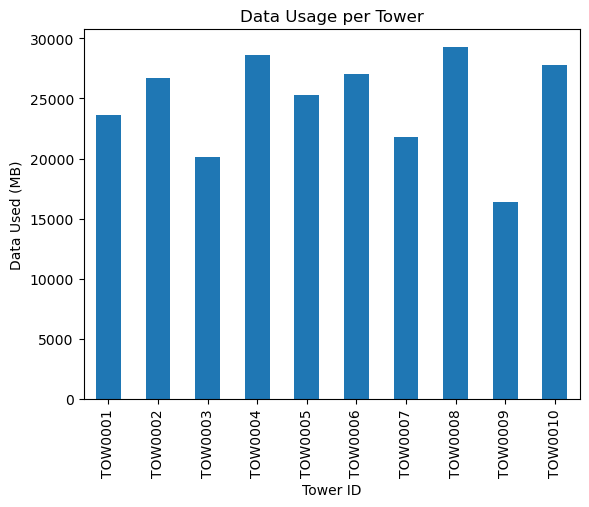

In [78]:
df.groupby('tower_id')['data_used_mb'].sum().head(10).plot(kind='bar')
plt.title('Data Usage per Tower')
plt.xlabel('Tower ID')
plt.ylabel('Data Used (MB)')
plt.show()

### Insight 
- Tower that is highly utilized in terms of data needs modern infrastructure and capacity planning, particularly of 4G/5G services, to achieve smooth operation in high-demand regions.

50. Overall Network Utilization

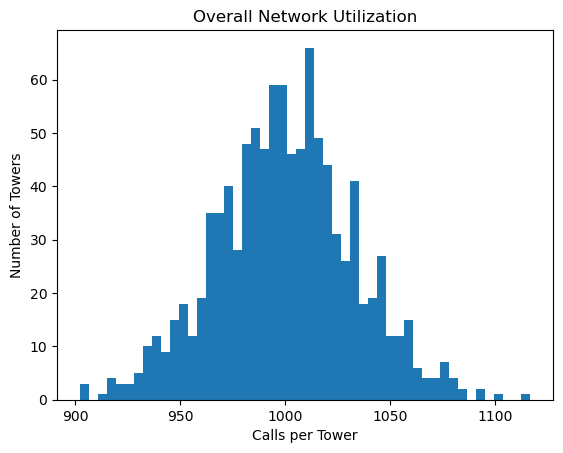

In [84]:
plt.hist(df['tower_id'].value_counts(), bins=50)
plt.title('Overall Network Utilization')
plt.xlabel('Calls per Tower')
plt.ylabel('Number of Towers')
plt.show()

### Insight
- Tower-level usage distribution displays network load in general, which can help manage the infrastructure and capacity on a long-term basis.